In [1]:
import hashlib
import json
import math
import os
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

In [2]:
try:
    import open_clip
    from huggingface_hub import hf_hub_download
except ImportError:
    !pip install -q open_clip_torch huggingface_hub
    import open_clip
    from huggingface_hub import hf_hub_download

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00


## 1. Configuración global

In [3]:
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

INPUT_ROOT = Path('/kaggle/input')
WORK_DIR = Path('/kaggle/working')

DATASET_CANDIDATES = [
    INPUT_ROOT / 'datasets/edwardsx/geovision-tiles-sit2',
    INPUT_ROOT / 'geovision-tiles-sit2',
]
DATASET_DIR = next((p for p in DATASET_CANDIDATES if p.exists()), DATASET_CANDIDATES[-1])

MODEL_CANDIDATES = [
    INPUT_ROOT / 'datasets/edwardsx/geovision-clip-modelo-v2',
    INPUT_ROOT / 'geovision-clip-modelo-v2',
]
MODEL_DIR = next((p for p in MODEL_CANDIDATES if p.exists()), MODEL_CANDIDATES[-1])

OUT_DIR = WORK_DIR / 'sit2_1_clip_reparacion_metricas'
CKPT_DIR = OUT_DIR / 'checkpoints'
FIG_DIR = OUT_DIR / 'figures'
for path in [OUT_DIR, CKPT_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TILES_PATH = DATASET_DIR / 'tiles_train.npz'
META_PATH = DATASET_DIR / 'tiles_meta.parquet'

BAND_NAMES = ['B1','B2','B3','B4','B5','B6','B7','B8','B8A','B9','B11','B12','SCL']
OPTICAL_BANDS = list(range(12))
OPTICAL_NAMES = BAND_NAMES[:12]
CLASES = ['contaminacion_alta_NO2', 'contaminacion_alta_SO2', 'ozono_anomalo', 'vegetacion_densa', 'suelo_urbano']

REMOTECLIP_REPO = 'chendelong/RemoteCLIP'
REMOTECLIP_FILE = 'RemoteCLIP-ViT-B-32.pt'

BATCH_SIZE = 64
NUM_WORKERS = 0
EPOCHS = 20
PATIENCE = 3
LR = 2e-5
WEIGHT_DECAY = 0.2
LORA_RANK = 16
IMAGE_SIZE = 224

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print('DEVICE:', DEVICE)
print('DATASET_DIR:', DATASET_DIR)
print('MODEL_DIR:', MODEL_DIR)
print('OUT_DIR:', OUT_DIR)

DEVICE: cuda
DATASET_DIR: /kaggle/input/datasets/edwardsx/geovision-tiles-sit2
MODEL_DIR: /kaggle/input/geovision-clip-modelo-v2
OUT_DIR: /kaggle/working/sit2_1_clip_reparacion_metricas


In [4]:
data = np.load(TILES_PATH, allow_pickle=False)
if 'tiles' in data.files:
    tiles = data['tiles']
elif 'data' in data.files:
    tiles = data['data']
else:
    tiles = data[data.files[0]]

meta = pd.read_parquet(META_PATH).reset_index(drop=True)

print('Tiles:', tiles.shape, tiles.dtype)
print('Meta:', meta.shape)
print(meta['clase'].value_counts().sort_index())
print('Fechas únicas:', meta['time_s2'].nunique() if 'time_s2' in meta.columns else 'no disponible')

Tiles: (5000, 13, 64, 64) float32
Meta: (5000, 22)
clase
contaminacion_alta_NO2    1000
contaminacion_alta_SO2    1000
ozono_anomalo             1000
suelo_urbano              1000
vegetacion_densa          1000
Name: count, dtype: int64
Fechas únicas: 79


In [5]:
indices = np.arange(len(meta))
train_idx, temp_idx = train_test_split(
    indices,
    train_size=0.70,
    random_state=SEED,
    stratify=meta['clase'],
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=meta.loc[temp_idx, 'clase'],
)

split_map = pd.Series(index=meta.index, dtype='object')
split_map.iloc[train_idx] = 'train'
split_map.iloc[val_idx] = 'val'
split_map.iloc[test_idx] = 'test'
meta['split_sit2_1'] = split_map

print(meta.groupby(['split_sit2_1', 'clase']).size().unstack(fill_value=0))
print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))

clase         contaminacion_alta_NO2  contaminacion_alta_SO2  ozono_anomalo  \
split_sit2_1                                                                  
test                             150                     150            150   
train                            700                     700            700   
val                              150                     150            150   

clase         suelo_urbano  vegetacion_densa  
split_sit2_1                                  
test                   150               150  
train                  700               700  
val                    150               150  
Train/Val/Test: 3500 750 750


In [6]:
train_tiles = tiles[train_idx][:, OPTICAL_BANDS].astype(np.float32)
band_mean = train_tiles.mean(axis=(0, 2, 3))
band_std = train_tiles.std(axis=(0, 2, 3)) + 1e-6

norm_stats = {
    'band_names': OPTICAL_NAMES,
    'mean': band_mean.tolist(),
    'std': band_std.tolist(),
    'source': 'train split only',
}
with open(OUT_DIR / 'normalization_train_only.json', 'w') as f:
    json.dump(norm_stats, f, indent=2)

print('Band mean:', np.round(band_mean, 2))
print('Band std:', np.round(band_std, 2))

Band mean: [ 839.1   899.36 1078.99 1015.82 1391.8  2335.84 2736.64 2695.49 2944.17
 2917.74 2217.4  1610.46]
Band std: [ 773.9   846.42  794.67  858.79  776.23  740.14  890.85  919.14  948.44
 1014.35  812.18  956.35]


In [7]:
TEXT_TEMPLATES = {
    'contaminacion_alta_NO2': [
        'urban tile with elevated nitrogen dioxide signal',
        'industrial and traffic area with high NO2 column',
        'satellite view associated with high NO2 pollution',
        'Cali urban region with elevated NO2 pseudo label',
        'remote sensing tile showing nitrogen dioxide hotspot',
    ],
    'contaminacion_alta_SO2': [
        'tile associated with elevated sulfur dioxide signal',
        'industrial atmospheric plume with high SO2 column',
        'satellite view associated with high SO2 pollution',
        'Cali region with sulfur dioxide pseudo label',
        'remote sensing tile showing SO2 hotspot',
    ],
    'ozono_anomalo': [
        'tile associated with anomalous ozone column',
        'dry season atmospheric regime with high O3 column',
        'satellite view associated with elevated ozone signal',
        'Cali region with anomalous O3 pseudo label',
        'remote sensing tile showing ozone anomaly',
    ],
    'vegetacion_densa': [
        'dense healthy vegetation with high NDVI',
        'green vegetated landscape in Sentinel-2 imagery',
        'remote sensing tile dominated by dense vegetation',
        'high NDVI vegetation cover in Cali region',
        'natural or agricultural vegetation with strong NIR response',
    ],
    'suelo_urbano': [
        'urban built-up surface with low vegetation',
        'city tile with roads buildings and sparse vegetation',
        'remote sensing tile dominated by urban land cover',
        'low NDVI urban surface near monitoring stations',
        'built environment pattern in Sentinel-2 imagery',
    ],
}

def build_text(row, variant=0):
    templates = TEXT_TEMPLATES[row['clase']]
    return templates[variant % len(templates)]

meta['texto_sit2_1'] = [build_text(row, i) for i, row in meta.iterrows()]
print(meta[['clase', 'texto_sit2_1']].head())

                    clase                                       texto_sit2_1
0  contaminacion_alta_NO2   urban tile with elevated nitrogen dioxide signal
1  contaminacion_alta_NO2   industrial and traffic area with high NO2 column
2  contaminacion_alta_NO2  satellite view associated with high NO2 pollution
3  contaminacion_alta_NO2   Cali urban region with elevated NO2 pseudo label
4  contaminacion_alta_NO2  remote sensing tile showing nitrogen dioxide h...


In [8]:
class TilesClipDataset(Dataset):
    def __init__(self, tiles, meta, indices, band_mean, band_std, train=False):
        self.tiles = tiles
        self.meta = meta.reset_index(drop=True)
        self.indices = np.asarray(indices)
        self.band_mean = torch.tensor(band_mean, dtype=torch.float32).view(12, 1, 1)
        self.band_std = torch.tensor(band_std, dtype=torch.float32).view(12, 1, 1)
        self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = int(self.indices[item])
        x = torch.tensor(self.tiles[idx, OPTICAL_BANDS].astype(np.float32))
        x = (x - self.band_mean) / self.band_std
        x = torch.clamp(x, -3.0, 3.0)
        if self.train:
            if torch.rand(()) < 0.5:
                x = torch.flip(x, dims=[2])
            k = int(torch.randint(0, 4, ()).item())
            x = torch.rot90(x, k, dims=[1, 2])
        x = F.interpolate(
            x.unsqueeze(0),
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode='bilinear',
            align_corners=False,
        ).squeeze(0)
        row = self.meta.loc[idx]
        return {
            'image': x,
            'text': row['texto_sit2_1'],
            'label': row['clase'],
            'index': int(idx),
        }


def collate_fn(batch):
    return {
        'image': torch.stack([b['image'] for b in batch]),
        'text': [b['text'] for b in batch],
        'label': [b['label'] for b in batch],
        'index': torch.tensor([b['index'] for b in batch], dtype=torch.long),
    }

In [9]:
train_ds = TilesClipDataset(tiles, meta, train_idx, band_mean, band_std, train=True)
val_ds = TilesClipDataset(tiles, meta, val_idx, band_mean, band_std, train=False)
test_ds = TilesClipDataset(tiles, meta, test_idx, band_mean, band_std, train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Batches:', len(train_loader), len(val_loader), len(test_loader))

Dataset sizes: 3500 750 750
Batches: 54 12 12


In [10]:
class LoRALinear(nn.Module):
    def __init__(self, linear: nn.Linear, rank: int = 16):
        super().__init__()
        self.linear = linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False
        d, k = linear.weight.shape
        self.A = nn.Parameter(torch.randn(d, rank) * 0.01)
        self.B = nn.Parameter(torch.zeros(rank, k))

    @property
    def weight(self):
        return self.linear.weight

    @weight.setter
    def weight(self, w):
        self.linear.weight = w

    @property
    def bias(self):
        return self.linear.bias

    @bias.setter
    def bias(self, b):
        self.linear.bias = b

    def forward(self, x):
        return self.linear(x) + F.linear(x, self.A @ self.B)


def aplicar_lora(module, rank=16, nombres_lora=None):
    if nombres_lora is None:
        nombres_lora = {'out_proj', 'c_fc', 'c_proj'}
    for name, child in module.named_children():
        if isinstance(child, nn.Linear) and name in nombres_lora:
            setattr(module, name, LoRALinear(child, rank))
        else:
            aplicar_lora(child, rank, nombres_lora)


class VisualProj(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        return self.proj(x)

In [11]:
ckpt_path = hf_hub_download(repo_id=REMOTECLIP_REPO, filename=REMOTECLIP_FILE)
remote_ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
clip_model, _, _ = open_clip.create_model_and_transforms('ViT-B-32', pretrained=None)
clip_model.load_state_dict(remote_ckpt, strict=False)
print(f'Modelo base cargado: {REMOTECLIP_FILE}')

RemoteCLIP-ViT-B-32.pt:   0%|          | 0.00/605M [00:00<?, ?B/s]

Modelo base cargado: RemoteCLIP-ViT-B-32.pt


In [12]:
for p in clip_model.parameters():
    p.requires_grad = False

aplicar_lora(clip_model.visual.transformer.resblocks[6:], rank=LORA_RANK)
aplicar_lora(clip_model.transformer.resblocks[6:], rank=LORA_RANK)

for name, p in clip_model.named_parameters():
    if any(k in name for k in ['text_projection', 'ln_final', 'ln_post', 'logit_scale']):
        p.requires_grad = True
    if 'visual.proj' in name:
        p.requires_grad = True

n_wrapped = sum(1 for m in clip_model.modules() if isinstance(m, LoRALinear))
print('Capas LoRA:', n_wrapped)

Capas LoRA: 36


In [13]:
orig_conv = clip_model.visual.conv1
new_conv = nn.Conv2d(12, orig_conv.out_channels, orig_conv.kernel_size, stride=orig_conv.stride, bias=False)
with torch.no_grad():
    idx_r = OPTICAL_NAMES.index('B4')
    idx_g = OPTICAL_NAMES.index('B3')
    idx_b = OPTICAL_NAMES.index('B2')
    w_new = new_conv.weight.data
    w_new[:, idx_r] = orig_conv.weight[:, 0]
    w_new[:, idx_g] = orig_conv.weight[:, 1]
    w_new[:, idx_b] = orig_conv.weight[:, 2]
    rgb_mean = orig_conv.weight.mean(dim=1, keepdim=False)
    for b in range(12):
        if b not in (idx_r, idx_g, idx_b):
            w_new[:, b] = rgb_mean * (3.0 / 12)
    new_conv.weight.copy_(w_new)
clip_model.visual.conv1 = new_conv
print('conv1 adaptada:', new_conv.in_channels, '->', new_conv.out_channels)

conv1 adaptada: 12 -> 768


In [14]:
clip_model = clip_model.to(DEVICE)
fusion = VisualProj(512).to(DEVICE)

trainable_params = [p for p in clip_model.parameters() if p.requires_grad] + list(fusion.parameters())
optimizer = torch.optim.AdamW(trainable_params, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

trainable_clip = sum(p.numel() for p in clip_model.parameters() if p.requires_grad)
trainable_fusion = sum(p.numel() for p in fusion.parameters())
print(f'Trainable clip params: {trainable_clip/1e6:.2f}M')
print(f'Trainable fusion params: {trainable_fusion/1e6:.2f}M')
print(f'Trainable total params: {(trainable_clip + trainable_fusion)/1e6:.2f}M')

Trainable clip params: 11.57M
Trainable fusion params: 0.26M
Trainable total params: 11.83M


In [15]:
tokenizer = open_clip.get_tokenizer('ViT-B-32')

def info_nce_loss(image_features, text_features, logit_scale):
    image_features = F.normalize(image_features, dim=-1)
    text_features = F.normalize(text_features, dim=-1)
    scale = logit_scale.exp().clamp(max=100)
    logits = scale * image_features @ text_features.T
    labels = torch.arange(logits.shape[0], device=logits.device)
    loss_i = F.cross_entropy(logits, labels)
    loss_t = F.cross_entropy(logits.T, labels)
    return 0.5 * (loss_i + loss_t), logits


def encode_batch(model, fusion_head, images, texts):
    images = images.to(DEVICE, non_blocking=True)
    tokens = tokenizer(texts).to(DEVICE)
    image_features = model.encode_image(images)
    image_features = fusion_head(image_features)
    text_features = model.encode_text(tokens)
    return image_features, text_features

In [16]:
def run_epoch(loader, train=False):
    clip_model.train(train)
    fusion.train(train)
    total_loss = 0.0
    steps = 0
    for batch in tqdm(loader, leave=False):
        if train:
            optimizer.zero_grad(set_to_none=True)
        image_features, text_features = encode_batch(clip_model, fusion, batch['image'], batch['text'])
        loss, _ = info_nce_loss(image_features, text_features, clip_model.logit_scale)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()
        total_loss += loss.item()
        steps += 1
    return total_loss / max(steps, 1)

best_val = float('inf')
best_epoch = 0
patience_count = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    with torch.no_grad():
        val_loss = run_epoch(val_loader, train=False)
    scheduler.step()
    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'logit_scale': float(clip_model.logit_scale.detach().exp().cpu().clamp(max=100)),
        'lr': scheduler.get_last_lr()[0],
    }
    history.append(row)
    print(f"Epoch {epoch:02d} | train={train_loss:.4f} val={val_loss:.4f} scale={row['logit_scale']:.2f}")

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        patience_count = 0
        torch.save({
            'clip': clip_model.state_dict(),
            'fusion': fusion.state_dict(),
            'epoch': epoch,
            'val_loss': val_loss,
            'band_mean': band_mean.tolist(),
            'band_std': band_std.tolist(),
            'split': {'train': train_idx.tolist(), 'val': val_idx.tolist(), 'test': test_idx.tolist()},
        }, CKPT_DIR / 'clip_v3_reparacion_metricas_best.pt')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print('Early stopping en epoch', epoch)
            break

history_df = pd.DataFrame(history)
history_df.to_csv(OUT_DIR / 'train_log.csv', index=False)
print('Mejor epoch:', best_epoch, 'val_loss:', best_val)

  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 01 | train=4.0878 val=3.7687 scale=99.67


  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

...

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 05 | train=3.6316 val=3.7184 scale=99.18


  0%|          | 0/54 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

Epoch 06 | train=3.5875 val=3.7127 scale=99.10
Early stopping en epoch 6
Mejor epoch: 3 val_loss: 3.708628555138906


In [17]:
best_ckpt = torch.load(CKPT_DIR / 'clip_v3_reparacion_metricas_best.pt', map_location=DEVICE, weights_only=True)
clip_model.load_state_dict(best_ckpt['clip'])
fusion.load_state_dict(best_ckpt['fusion'])
clip_model.eval()
fusion.eval()
print('Checkpoint cargado:', best_ckpt['epoch'], best_ckpt['val_loss'])

Checkpoint cargado: 3 3.708628555138906


In [18]:
@torch.no_grad()
def collect_embeddings(loader):
    image_embs, text_embs, labels, indices_out, texts_out = [], [], [], [], []
    clip_model.eval()
    fusion.eval()
    for batch in tqdm(loader, desc='Embeddings', leave=False):
        image_features, text_features = encode_batch(clip_model, fusion, batch['image'], batch['text'])
        image_embs.append(image_features.detach().cpu())
        text_embs.append(text_features.detach().cpu())
        labels.extend(batch['label'])
        indices_out.extend(batch['index'].tolist())
        texts_out.extend(batch['text'])
    return {
        'image': torch.cat(image_embs),
        'text': torch.cat(text_embs),
        'label': np.array(labels),
        'index': np.array(indices_out),
        'text_raw': texts_out,
    }

train_emb = collect_embeddings(DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn))
val_emb = collect_embeddings(val_loader)
test_emb = collect_embeddings(test_loader)
print('Embeddings train/val/test:', train_emb['image'].shape, val_emb['image'].shape, test_emb['image'].shape)

Embeddings:   0%|          | 0/55 [00:00<?, ?it/s]

Embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Embeddings train/val/test: torch.Size([3500, 512]) torch.Size([750, 512]) torch.Size([750, 512])


In [19]:
def recall_at_k_pairwise(image_embeddings, text_embeddings, ks=(1, 5, 10)):
    image_embeddings = F.normalize(image_embeddings, dim=-1)
    text_embeddings = F.normalize(text_embeddings, dim=-1)
    sims = image_embeddings @ text_embeddings.T
    targets = torch.arange(sims.shape[0])
    out = {}
    for k in ks:
        k_eff = min(k, sims.shape[1])
        topk = sims.topk(k_eff, dim=1).indices
        out[f'retrieval_r@{k}'] = (topk == targets[:, None]).any(dim=1).float().mean().item()
    return out

retrieval_val = recall_at_k_pairwise(val_emb['image'], val_emb['text'])
retrieval_test = recall_at_k_pairwise(test_emb['image'], test_emb['text'])
print('Retrieval real val:', retrieval_val)
print('Retrieval real test:', retrieval_test)

Retrieval real val: {'retrieval_r@1': 0.006666666828095913, 'retrieval_r@5': 0.019999999552965164, 'retrieval_r@10': 0.035999998450279236}
Retrieval real test: {'retrieval_r@1': 0.0026666666381061077, 'retrieval_r@5': 0.014666666276752949, 'retrieval_r@10': 0.024000000208616257}


In [20]:
@torch.no_grad()
def build_text_prototypes():
    proto = []
    for clase in CLASES:
        texts = TEXT_TEMPLATES[clase]
        text_features = clip_model.encode_text(tokenizer(texts).to(DEVICE))
        text_features = F.normalize(text_features, dim=-1).mean(dim=0)
        text_features = F.normalize(text_features, dim=0)
        proto.append(text_features.cpu())
    return torch.stack(proto)

PROTO_EMBS = build_text_prototypes()

def class_prototype_metrics(emb_pack, split_name):
    image_emb = F.normalize(emb_pack['image'], dim=-1)
    sims = image_emb @ PROTO_EMBS.T
    pred_idx = sims.argmax(dim=1).numpy()
    pred = np.array([CLASES[i] for i in pred_idx])
    y = emb_pack['label']
    top3 = sims.topk(3, dim=1).indices.numpy()
    top3_ok = np.mean([y[i] in [CLASES[j] for j in top3[i]] for i in range(len(y))])
    acc = accuracy_score(y, pred)
    cm = confusion_matrix(y, pred, labels=CLASES)
    pd.DataFrame(cm, index=CLASES, columns=CLASES).to_csv(OUT_DIR / f'confusion_{split_name}.csv')
    return {'class_prototype_acc': float(acc), 'class_prototype_top3': float(top3_ok)}, pred

prototype_val, pred_val = class_prototype_metrics(val_emb, 'val')
prototype_test, pred_test = class_prototype_metrics(test_emb, 'test')
print('Prototype val:', prototype_val)
print('Prototype test:', prototype_test)
print(classification_report(test_emb['label'], pred_test, labels=CLASES, digits=3))

Prototype val: {'class_prototype_acc': 0.484, 'class_prototype_top3': 0.928}
Prototype test: {'class_prototype_acc': 0.496, 'class_prototype_top3': 0.9253333333333333}
                        precision    recall  f1-score   support

contaminacion_alta_NO2      0.416     0.280     0.335       150
contaminacion_alta_SO2      0.360     0.240     0.288       150
         ozono_anomalo      0.406     0.347     0.374       150
      vegetacion_densa      0.513     0.680     0.585       150
          suelo_urbano      0.631     0.933     0.753       150

              accuracy                          0.496       750
             macro avg      0.465     0.496     0.467       750
          weighted avg      0.465     0.496     0.467       750



In [21]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(F.normalize(train_emb['image'], dim=-1).numpy(), train_emb['label'])
knn_val = knn.score(F.normalize(val_emb['image'], dim=-1).numpy(), val_emb['label'])
knn_test = knn.score(F.normalize(test_emb['image'], dim=-1).numpy(), test_emb['label'])
print(f'kNN val={knn_val:.3f} test={knn_test:.3f}')

kNN val=0.407 test=0.404


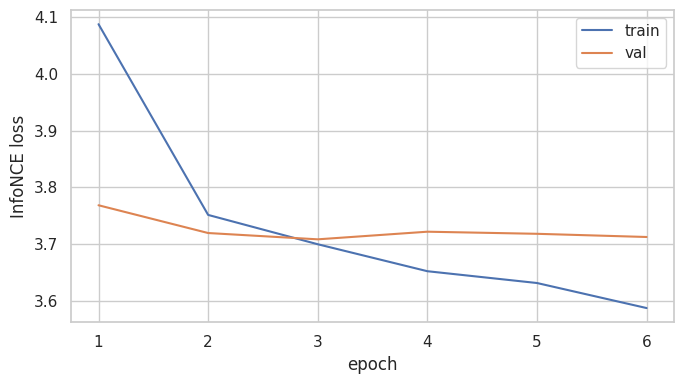

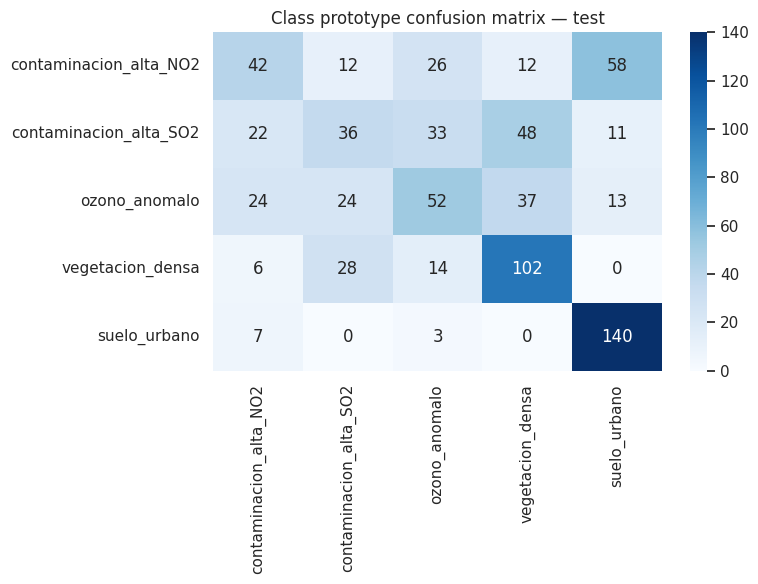

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
if len(history_df):
    ax.plot(history_df['epoch'], history_df['train_loss'], label='train')
    ax.plot(history_df['epoch'], history_df['val_loss'], label='val')
    ax.set_xlabel('epoch')
    ax.set_ylabel('InfoNCE loss')
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'training_curves.png', dpi=160)
plt.show()

cm_test = pd.read_csv(OUT_DIR / 'confusion_test.csv', index_col=0)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Class prototype confusion matrix — test')
fig.tight_layout()
fig.savefig(FIG_DIR / 'confusion_test.png', dpi=160)
plt.show()

In [23]:
ckpt_path = CKPT_DIR / 'clip_v3_reparacion_metricas_best.pt'
md5 = hashlib.md5(ckpt_path.read_bytes()).hexdigest()

metrics = {
    'split': '70/15/15 stratified',
    'normalization': 'train only',
    'optimizer_includes_fusion': True,
    'logit_scale_uses_exp': True,
    'best_epoch': int(best_epoch),
    'best_val_loss': float(best_val),
    'retrieval_val': retrieval_val,
    'retrieval_test': retrieval_test,
    'class_prototype_val': prototype_val,
    'class_prototype_test': prototype_test,
    'knn_acc_k5_val': float(knn_val),
    'knn_acc_k5_test': float(knn_test),
    'checkpoint_md5': md5,
}
with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

with open(OUT_DIR / 'checkpoint.md5', 'w') as f:
    f.write(md5)

print(json.dumps(metrics, indent=2))

{
  "split": "70/15/15 stratified",
  "normalization": "train only",
  "optimizer_includes_fusion": true,
  "logit_scale_uses_exp": true,
  "best_epoch": 3,
  "best_val_loss": 3.708628555138906,
  "retrieval_val": {
    "retrieval_r@1": 0.006666666828095913,
    "retrieval_r@5": 0.019999999552965164,
    "retrieval_r@10": 0.035999998450279236
  },
  "retrieval_test": {
    "retrieval_r@1": 0.0026666666381061077,
    "retrieval_r@5": 0.014666666276752949,
    "retrieval_r@10": 0.024000000208616257
  },
  "class_prototype_val": {
    "class_prototype_acc": 0.484,
    "class_prototype_top3": 0.928
  },
  "class_prototype_test": {
    "class_prototype_acc": 0.496,
    "class_prototype_top3": 0.9253333333333333
  },
  "knn_acc_k5_val": 0.4066666666666667,
  "knn_acc_k5_test": 0.404,
  "checkpoint_md5": "2236b23237519702a5ebadd9e956c881"
}
